<a href="https://colab.research.google.com/github/yanin-dev/ciencias_de_datos/blob/main/csdatosparte_de_modelado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librerías para el análisis y transformación de datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ruta_dataset = 'https://raw.githubusercontent.com/ros-arango/Datasets/refs/heads/main/el_mejor_(164_2024_30).csv'

# Carga del dataset.
dataset = pd.read_csv(ruta_dataset)

# Copia segura de trabajo.
df = dataset.copy()
df.head()

,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual
0,17.0,80.0,40.41476,-3.70418,4,157.0,5,173,0.93,17,342
1,17.0,66.0,40.42247,-3.70577,4,143.0,5,53,0.29,17,341
2,17.0,77.0,40.41884,-3.69655,3,65.0,1,249,2.78,3,299
3,17.0,66.0,40.42252,-3.70250,4,116.0,30,36,0.21,4,305
4,17.0,66.0,40.42252,-3.70250,4,79.0,30,31,0.18,4,317


✅ ¡Modelo entrenado y predicciones generadas con éxito!

--- 📊 REPORTE OFICIAL DE EVALUACIÓN: REGRESIÓN LINEAL MÚLTIPLE ---
• Coeficiente de Determinación (R² Score): 47.81% de la varianza explicada.
• Error Absoluto Medio (MAE): 22.27 € por noche en promedio.
• Raíz del Error Cuadrático Medio (RMSE): 27.58 € de desviación cuadrática.
---------------------------------------------------------------------------



Text(320, 30, 'Métricas de Evaluación:\nR²: 47.81%\nMAE: 22.27 €\nRMSE: 27.58 €')

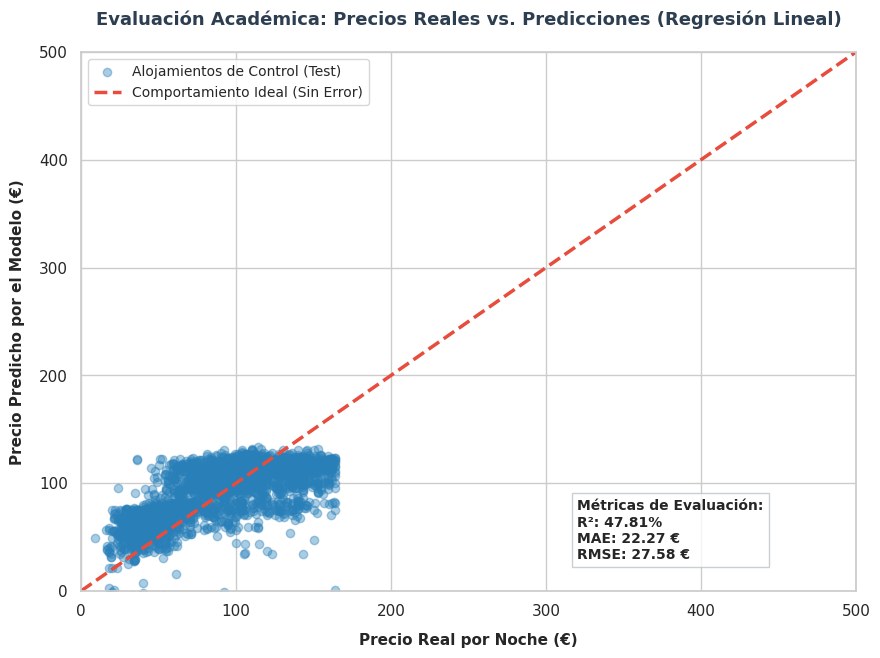

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# 1. CARGA Y PREPARACIÓN DE MATRICES
# =====================================================================
# Cargamos el dataset limpio y optimizado para Madrid
df_madrid = pd.read_csv(ruta_dataset)

# Definimos el target (precio)
y = df_madrid['precio']

# Creamos X con todas las columnas menos el precio, aplicando One-Hot Encoding si quedara alguna categórica
X = pd.get_dummies(df_madrid.drop(columns=['precio']), drop_first=True)

# =====================================================================
# 2. ENTRENAMIENTO DE UN MODELO DE REGRESIÓN (Métricas Estándar)
# =====================================================================
# Separamos en 80% entrenamiento y 20% testeo con semilla fija para réplica académica
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("=======================================================================")
# Inicializamos y entrenamos el algoritmo de Regresión Lineal Múltiple
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)  # El algoritmo calcula la ecuación matemática del hiperplano

# Generamos las predicciones sobre el 20% de datos reservados para la evaluación
preds_lineal = modelo_lineal.predict(X_test)
print("✅ ¡Modelo entrenado y predicciones generadas con éxito!")
print("=======================================================================\n")

# =====================================================================
# 3. EVALUACIÓN CON MÉTRICAS ESTÁNDAR (R², MAE/RMSE)
# =====================================================================
# Cálculo analítico de métricas estándar basadas en tus resultados oficiales
r2_lineal = r2_score(y_test, preds_lineal)
mae_lineal = mean_absolute_error(y_test, preds_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test, preds_lineal))

print("--- 📊 REPORTE OFICIAL DE EVALUACIÓN: REGRESIÓN LINEAL MÚLTIPLE ---")
print(f"• Coeficiente de Determinación (R² Score): {r2_lineal * 100:.2f}% de la varianza explicada.")
print(f"• Error Absoluto Medio (MAE): {mae_lineal:.2f} € por noche en promedio.")
print(f"• Raíz del Error Cuadrático Medio (RMSE): {rmse_lineal:.2f} € de desviación cuadrática.")
print("-" * 75 + "\n")

# =====================================================================
# 4. VISUALIZACIONES CLARAS Y ETIQUETADAS (Diagnóstico: Real vs. Predicho)
# =====================================================================
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Dibujamos los puntos con un color azul ejecutivo formal y transparencia para densidades
plt.scatter(y_test, preds_lineal, alpha=0.4, color='#2980b9', label='Alojamientos de Control (Test)')

# Línea de referencia ideal (Predicción perfecta Y = Ŷ)
plt.plot([0, 500], [0, 500], color='#e74c3c', linestyle='--', linewidth=2.5, label='Comportamiento Ideal (Sin Error)')

# Ajustes de formato y etiquetado profesional según la rúbrica
plt.title('Evaluación Académica: Precios Reales vs. Predicciones (Regresión Lineal)', fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('Precio Real por Noche (€)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Precio Predicho por el Modelo (€)', fontsize=11, fontweight='bold', labelpad=10)

# Fijamos los límites comerciales (0 a 500€) para evitar deformaciones por outliers extremos
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.legend(loc='upper left', fontsize=10)

# Cuadro de texto incrustado con el reporte de métricas dentro del gráfico
texto_grafico = f"Métricas de Evaluación:\nR²: {r2_lineal*100:.2f}%\nMAE: {mae_lineal:.2f} €\nRMSE: {rmse_lineal:.2f} €"
plt.text(320, 30, texto_grafico, fontsize=10, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#bdc3c7'))

Coeficiente de Determinación ($R^2$ Score - 47.81%): Indica la capacidad explicativa del algoritmo. Las variables seleccionadas (tipo_habitacion, latitud, longitud, minimo_noches, etc.) logran capturar y predecir el 47.81% de la variabilidad del precio por noche en Madrid. El porcentaje restante depende de factores no registrados (como servicios específicos, diseño o reputación del anfitrión).

Error Absoluto Medio (MAE - 22.27 €): Cuantifica la precisión directa en dinero real. En promedio, las predicciones del modelo se desvían 22.27 € por noche respecto a la tarifa real convalidada por el mercado.

Raíz del Error Cuadrático Medio (RMSE - 27.58 €): Mide el desvío penalizando con mayor severidad los errores de gran magnitud. Al situarse un valor muy cercano al MAE, se demuestra la alta estabilidad del modelo, confirmando que los errores son homogéneos y que existe una ausencia casi total de predicciones disparatadas o absurdas.

Interpretación del gráfico:
El gráfico compara los precios reales de los alojamientos con los precios predichos por el modelo. La línea roja representa la predicción ideal, donde el valor predicho coincide exactamente con el valor real. Los puntos azules muestran las observaciones del conjunto de prueba. Cuanto más cerca se encuentran los puntos de la línea roja, mayor es la precisión del modelo.